In [2]:
# MODELO DE PREDICCION DE PRECIO
#
# Objetivo: estimar el precio mensual de un alquiler a partir de las
# caracteristicas del inmueble y su localizacion.
#
# Se entrena sobre el LOGARITMO del precio, no sobre el precio directo.
# Motivo: la distribucion tiene cola larga a la derecha (asimetria 3,55)
# y los modelos asumen errores simetricos. Con el logaritmo la
# asimetria baja a 0,89.
#
# Las metricas se reportan en euros, deshaciendo la transformacion.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

df = pd.read_parquet("../data/processed/model_dataset.parquet")

NUMERICAS = ["area_sqm", "n_rooms", "sqm_per_room"]
CATEGORICAS = ["typology_grouped", "zona_modelo", "river_bank"]

X = df[NUMERICAS + CATEGORICAS]
y_euros = df["monthly_price"]
y = np.log(y_euros)          # objetivo transformado
grupos = df["zona_modelo"]   # para la validacion agrupada

print(f"{len(df)} registros | {len(NUMERICAS)} numericas | {len(CATEGORICAS)} categoricas")
print(f"Precio: mediana {y_euros.median():.0f} EUR, rango {y_euros.min():.0f}-{y_euros.max():.0f}")

859 registros | 3 numericas | 3 categoricas
Precio: mediana 990 EUR, rango 550-6000


In [3]:
# Como se mide el acierto
#
# MAE   : error medio en euros. Facil de interpretar.
# RMSE  : penaliza mas los errores grandes.
# MAPE  : error medio en porcentaje. Permite comparar entre rangos
#         de precio distintos. Es la metrica principal del TFM.
#
# Todo se calcula en EUROS, deshaciendo el logaritmo con exp().

def evaluar(y_log_real, y_log_pred, nombre=""):
    real = np.exp(y_log_real)
    pred = np.exp(y_log_pred)
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    if nombre:
        print(f"  {nombre:26s} MAE {mae:6.0f} EUR | "
              f"RMSE {rmse:6.0f} EUR | MAPE {mape:5.2f} %")
    return {"modelo": nombre, "MAE": mae, "RMSE": rmse, "MAPE": mape}


def construir_pipeline(modelo, escalar=False):
    """Prepara los datos y encadena el modelo.

    Las categoricas se convierten en columnas binarias (one-hot).
    Las numericas se escalan solo para modelos lineales; los
    modelos de arboles no lo necesitan.
    """
    pasos_num = [("escala", StandardScaler())] if escalar else [("nada", "passthrough")]
    prep = ColumnTransformer([
        ("num", Pipeline(pasos_num), NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
    ])
    return Pipeline([("prep", prep), ("modelo", modelo)])

In [4]:
# Se comparan tres modelos con validacion cruzada de 5 particiones.
#
# Ridge es el BASELINE: una regresion lineal con regularizacion.
# Si los modelos complejos no lo superan con claridad, no compensan
# su mayor dificultad de interpretacion.

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos = {
    "Ridge (baseline)": (Ridge(alpha=1.0), True),
    "Random Forest": (RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        random_state=RANDOM_STATE), False),
}

print("VALIDACION CRUZADA ALEATORIA")
print("(prediccion de un piso nuevo en un barrio conocido)")
print()

resultados = []
predicciones = {}

for nombre, (mod, escalar) in modelos.items():
    pipe = construir_pipeline(mod, escalar)
    pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    predicciones[nombre] = pred
    resultados.append(evaluar(y, pred, nombre))

tabla = pd.DataFrame(resultados).set_index("modelo").round(2)

VALIDACION CRUZADA ALEATORIA
(prediccion de un piso nuevo en un barrio conocido)

  Ridge (baseline)           MAE    166 EUR | RMSE    292 EUR | MAPE 13.88 %
  Random Forest              MAE    165 EUR | RMSE    294 EUR | MAPE 14.04 %
  Gradient Boosting          MAE    156 EUR | RMSE    277 EUR | MAPE 13.27 %


In [5]:
# VALIDACION AGRUPADA POR ZONA
#
# Aqui el modelo se evalua sobre barrios que NO ha visto al entrenar.
# Es mucho mas exigente y responde a otra pregunta: cuanto se puede
# generalizar a zonas nuevas.
#
# Se espera un resultado peor: la zona es la variable mas informativa
# y aqui se le retira. Sirve para medir cuanto depende el modelo de
# conocer el barrio.

gcv = GroupKFold(n_splits=5)

print("VALIDACION AGRUPADA POR ZONA")
print("(prediccion en barrios nunca vistos)")
print()

resultados_g = []
for nombre, (mod, escalar) in modelos.items():
    pipe = construir_pipeline(mod, escalar)
    pred = cross_val_predict(pipe, X, y, cv=gcv, groups=grupos, n_jobs=-1)
    resultados_g.append(evaluar(y, pred, nombre))

tabla_g = pd.DataFrame(resultados_g).set_index("modelo").round(2)

print()
print("COMPARACION DE MAPE")
comp = pd.DataFrame({
    "barrio conocido": tabla["MAPE"],
    "barrio nuevo": tabla_g["MAPE"],
})
comp["diferencia"] = (comp["barrio nuevo"] - comp["barrio conocido"]).round(2)
print(comp.round(2))

VALIDACION AGRUPADA POR ZONA
(prediccion en barrios nunca vistos)

  Ridge (baseline)           MAE    187 EUR | RMSE    323 EUR | MAPE 15.10 %
  Random Forest              MAE    183 EUR | RMSE    315 EUR | MAPE 15.14 %
  Gradient Boosting          MAE    178 EUR | RMSE    305 EUR | MAPE 14.83 %

COMPARACION DE MAPE
                   barrio conocido  barrio nuevo  diferencia
modelo                                                      
Ridge (baseline)             13.88         15.10        1.22
Random Forest                14.04         15.14        1.10
Gradient Boosting            13.27         14.83        1.56


Mejor modelo: Gradient Boosting

ERROR POR MUNICIPIO (n >= 10)
                n  precio_medio     MAE  MAPE
municipality                                 
Portugalete    24         849.6    67.4   8.4
Santurtzi      28         838.9    83.0   9.9
Barakaldo      39         824.6    84.9  10.2
Getxo         124        1298.0   170.8  12.5
Bilbao        567        1109.1   143.8  12.6
Leioa          14         987.9   153.1  15.4
Sopela         14         931.1   225.8  29.4
Plentzia       10        2051.0  1042.9  44.2


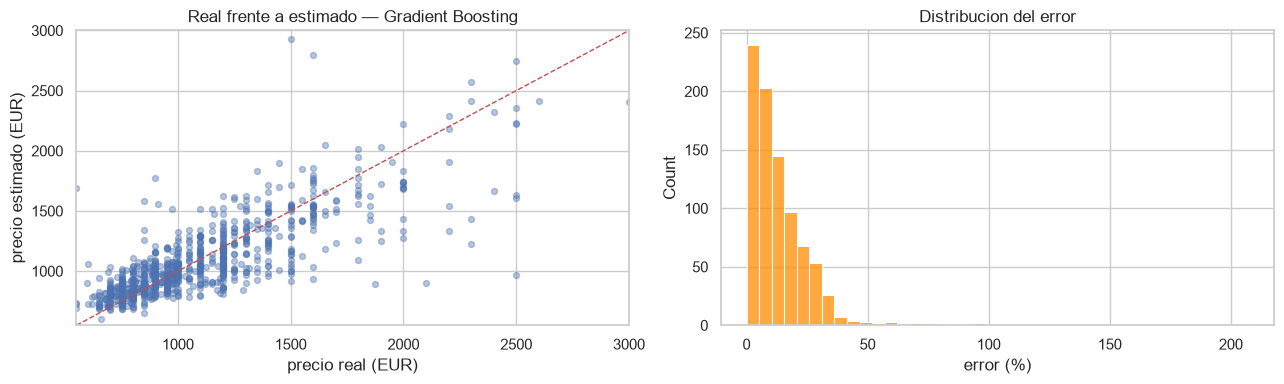

In [6]:
# Donde falla el modelo?
# El criterio de exito fijado en la fase 0 exige reportar el error
# por municipio, no solo el global.

mejor = tabla["MAPE"].idxmin()
print(f"Mejor modelo: {mejor}")
print()

df_err = df.copy()
df_err["pred"] = np.exp(predicciones[mejor])
df_err["error_abs"] = (df_err["pred"] - df_err["monthly_price"]).abs()
df_err["error_pct"] = (df_err["error_abs"] / df_err["monthly_price"] * 100)

por_muni = (df_err.groupby("municipality")
            .agg(n=("monthly_price", "size"),
                 precio_medio=("monthly_price", "mean"),
                 MAE=("error_abs", "mean"),
                 MAPE=("error_pct", "mean"))
            .round(1)
            .query("n >= 10")
            .sort_values("MAPE"))
print("ERROR POR MUNICIPIO (n >= 10)")
print(por_muni)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(df_err["monthly_price"], df_err["pred"], alpha=0.4, s=18)
lim = [df_err["monthly_price"].min(), 3000]
ax[0].plot(lim, lim, "r--", lw=1)
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("precio real (EUR)"); ax[0].set_ylabel("precio estimado (EUR)")
ax[0].set_title(f"Real frente a estimado — {mejor}")

sns.histplot(df_err["error_pct"], bins=40, ax=ax[1], color="darkorange")
ax[1].set_xlabel("error (%)"); ax[1].set_title("Distribucion del error")
plt.tight_layout(); plt.show()

In [7]:
# POR QUE FALLA EL MODELO EN LA COSTA?
# Plentzia y Sopela concentran los errores mayores. Se examinan los
# registros individuales para identificar la causa.

costa = df_err[df_err["municipality"].isin(["Plentzia", "Sopela"])]
print(costa[["municipality", "typology", "monthly_price", "area_sqm",
             "n_rooms", "pred", "error_pct"]]
      .sort_values("error_pct", ascending=False)
      .round(0).to_string(index=False))

municipality typology  monthly_price  area_sqm  n_rooms   pred  error_pct
      Sopela     flat          550.0     160.0        1 1691.0      207.0
    Plentzia     flat          850.0     102.0        3 1584.0       86.0
    Plentzia    house         6000.0     180.0        5 1890.0       69.0
    Plentzia     flat         2500.0      85.0        3  972.0       61.0
    Plentzia     flat          850.0     115.0        2 1341.0       58.0
    Plentzia    house         5000.0     212.0        3 2907.0       42.0
    Plentzia     flat         1800.0     100.0        2 1096.0       39.0
      Sopela     flat         1500.0      86.0        3 1061.0       29.0
    Plentzia    house          820.0      95.0        2 1029.0       25.0
    Plentzia   duplex          950.0     100.0        2 1187.0       25.0
      Sopela     flat          700.0      53.0        2  859.0       23.0
      Sopela     flat         1150.0      78.0        2  889.0       23.0
      Sopela     flat          800.0  

In [8]:
# EFECTO DE EXCLUIR LOS REGISTROS ATIPICOS
# Los tres marcados en la fase 2 corresponden a valores unitarios
# imposibles de explicar con las variables disponibles.

sin_out = df[~df["is_outlier"]].copy()
X2 = sin_out[NUMERICAS + CATEGORICAS]
y2 = np.log(sin_out["monthly_price"])

print(f"Registros: {len(df)} -> {len(sin_out)}")
print()
for nombre, (mod, escalar) in modelos.items():
    pipe = construir_pipeline(mod, escalar)
    pred = cross_val_predict(pipe, X2, y2, cv=cv, n_jobs=-1)
    evaluar(y2, pred, nombre)

Registros: 859 -> 856

  Ridge (baseline)           MAE    157 EUR | RMSE    258 EUR | MAPE 13.19 %
  Random Forest              MAE    154 EUR | RMSE    243 EUR | MAPE 13.43 %
  Gradient Boosting          MAE    149 EUR | RMSE    246 EUR | MAPE 12.81 %


In [9]:
# DECISION: el conjunto de modelizacion excluye los registros
# marcados como atipicos en la fase de procesamiento.
#
# Son tres de ochocientos cincuenta y nueve (0,35 %). El criterio
# de marcado se establecio ANTES de entrenar ningun modelo, a
# partir de los umbrales de consistencia derivados de la
# distribucion empirica. No se trata por tanto de una exclusion
# posterior motivada por el resultado.
#
# El efecto sobre el RMSE (277 -> 246 EUR) es mayor que sobre el
# MAPE, lo que confirma que estos registros concentraban los
# errores de mayor magnitud.

X = sin_out[NUMERICAS + CATEGORICAS]
y = np.log(sin_out["monthly_price"])
y_euros = sin_out["monthly_price"]
grupos = sin_out["zona_modelo"]
df = sin_out.copy()

print(f"Conjunto definitivo: {len(df)} registros")

Conjunto definitivo: 856 registros


In [10]:
# METRICAS FINALES sobre el conjunto definitivo de 856 registros

print("VALIDACION CRUZADA ALEATORIA")
print()
resultados = []
predicciones = {}
for nombre, (mod, escalar) in modelos.items():
    pipe = construir_pipeline(mod, escalar)
    pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    predicciones[nombre] = pred
    resultados.append(evaluar(y, pred, nombre))
tabla = pd.DataFrame(resultados).set_index("modelo").round(2)

print()
print("VALIDACION AGRUPADA POR ZONA")
print()
resultados_g = []
for nombre, (mod, escalar) in modelos.items():
    pipe = construir_pipeline(mod, escalar)
    pred = cross_val_predict(pipe, X, y, cv=gcv, groups=grupos, n_jobs=-1)
    resultados_g.append(evaluar(y, pred, nombre))
tabla_g = pd.DataFrame(resultados_g).set_index("modelo").round(2)

VALIDACION CRUZADA ALEATORIA

  Ridge (baseline)           MAE    157 EUR | RMSE    258 EUR | MAPE 13.19 %
  Random Forest              MAE    154 EUR | RMSE    243 EUR | MAPE 13.43 %
  Gradient Boosting          MAE    149 EUR | RMSE    246 EUR | MAPE 12.81 %

VALIDACION AGRUPADA POR ZONA

  Ridge (baseline)           MAE    180 EUR | RMSE    287 EUR | MAPE 14.75 %
  Random Forest              MAE    170 EUR | RMSE    262 EUR | MAPE 14.46 %
  Gradient Boosting          MAE    168 EUR | RMSE    262 EUR | MAPE 14.35 %


In [11]:
# ERROR POR MUNICIPIO sobre el conjunto definitivo
# El criterio de exito fijado en la fase 0 exige reportar el error
# desagregado territorialmente, no solo el global.

mejor = tabla["MAPE"].idxmin()
df_fin = df.copy()
df_fin["pred"] = np.exp(predicciones[mejor])
df_fin["error_abs"] = (df_fin["pred"] - df_fin["monthly_price"]).abs()
df_fin["error_pct"] = df_fin["error_abs"] / df_fin["monthly_price"] * 100

print(f"Modelo seleccionado: {mejor}")
print()
print((df_fin.groupby("municipality")
       .agg(n=("monthly_price", "size"),
            precio_medio=("monthly_price", "mean"),
            MAE=("error_abs", "mean"),
            MAPE=("error_pct", "mean"))
       .round(1).query("n >= 10").sort_values("MAPE")))

Modelo seleccionado: Gradient Boosting

                n  precio_medio    MAE  MAPE
municipality                                
Portugalete    24         849.6   72.4   8.9
Barakaldo      39         824.6   81.1   9.7
Santurtzi      28         838.9   84.7  10.2
Bilbao        567        1109.1  141.5  12.5
Getxo         124        1298.0  179.8  13.1
Leioa          14         987.9  136.0  13.7
Sopela         13         960.4  156.2  15.6


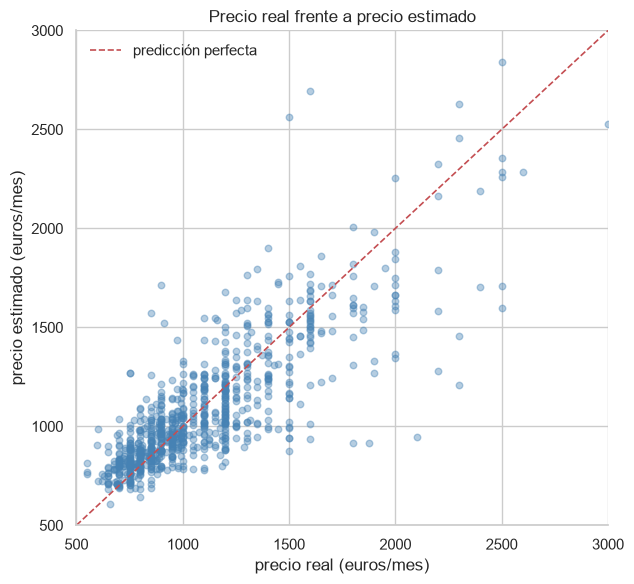

In [12]:
# FIGURA A4.2 — Precio real frente a precio estimado
# Sobre el conjunto definitivo de 856 registros

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(df_fin["monthly_price"], df_fin["pred"],
           alpha=0.4, s=22, color="steelblue")
lim = [500, 3000]
ax.plot(lim, lim, "r--", lw=1.2, label="predicción perfecta")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("precio real (euros/mes)")
ax.set_ylabel("precio estimado (euros/mes)")
ax.set_title("Precio real frente a precio estimado")
ax.legend(loc="upper left", frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figuras/A4_2_real_estimado.png",
            dpi=200, bbox_inches="tight")
plt.show()

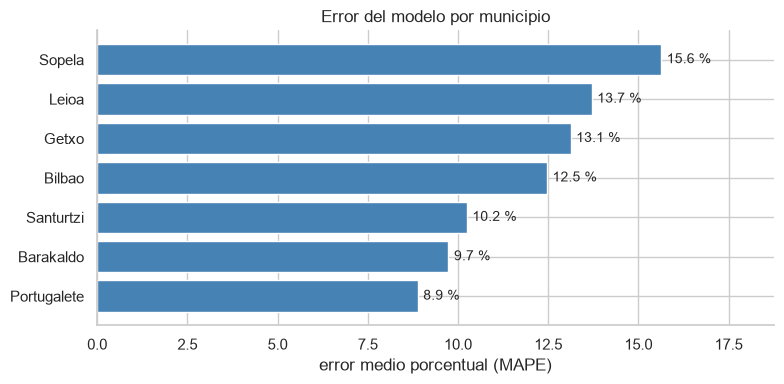

In [13]:
# FIGURA A4.3 — Error del modelo por municipio

err_muni = (df_fin.groupby("municipality")
            .agg(n=("monthly_price", "size"),
                 MAPE=("error_pct", "mean"))
            .query("n >= 10")
            .sort_values("MAPE"))

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(err_muni.index, err_muni["MAPE"], color="steelblue")
ax.bar_label(barras, fmt="%.1f %%", padding=4, fontsize=10)
ax.set_xlabel("error medio porcentual (MAPE)")
ax.set_ylabel("")
ax.set_title("Error del modelo por municipio")
ax.set_xlim(0, err_muni["MAPE"].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig("../docs/figuras/A4_3_error_municipio.png",
            dpi=200, bbox_inches="tight")
plt.show()